In [52]:
import pandas as pd
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import hashlib
from sklearn.model_selection import train_test_split



In [ ]:

HOUSING_PATH = 'datasets/housing/'

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path,'housing.csv')
    return pd.read_csv(csv_path)

In [ ]:
housing = load_housing_data()
housing.head()

In [ ]:
housing.info()

In [ ]:
housing["ocean_proximity"].value_counts()

In [ ]:
housing.shape

In [ ]:
housing.describe()

In [ ]:
housing.hist(bins=50,figsize=(20,15))
plt.show()


In [ ]:

np.random.seed(42)
print(np.random.permutation(4))
print(np.random.permutation(4))
print(np.random.permutation(4))
print(np.random.permutation(4))


In [56]:


def test_set_check(identifier, test_ratio, hash):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

def split_train_test_by_id(data, test_ratio, id_column, hash=hashlib.md5):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio, hash))
    return data.loc[~in_test_set], data.loc[in_test_set]

housing_with_id = housing.reset_index()   # adds an `index` column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

print(len(train_set), "train +", len(test_set), "test")

16362 train + 4278 test


In [ ]:
test_set.head()

In [60]:

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print(len(train_set), "train +", len(test_set), "test")

test_set.head()

16512 train + 4128 test


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND,2.0
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND,2.0
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY,3.0
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN,4.0
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN,3.0


In [ ]:
housing.hist()

In [ ]:
housing["median_income"].hist()

In [ ]:
housing["income_cat"] = np.ceil(housing["median_income"]/1.5)

In [ ]:
housing["income_cat"].value_counts()

In [ ]:

# Label those above 5 as 5
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)

In [ ]:
housing["income_cat"].value_counts()

In [ ]:
housing["income_cat"].hist()

<Axes: xlabel='longitude', ylabel='latitude'>

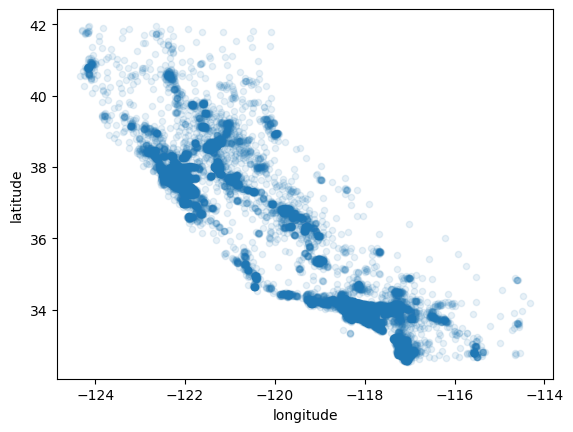

In [61]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)